# Week 5 — The Threshold Is a Product Decision

This experiment explores how changing a classification threshold changes the behaviour of a decision system.

The model stays the same.

The probability scores stay the same.

Only the threshold changes.

The goal is to show:

> Same model. Same scores. Different threshold. Different product outcome.

## Why this matters

In earlier experiments, I looked at accuracy, precision, recall, and the difference between model scores and final decisions.

This week focuses on the threshold.

A classification model usually produces a probability score.

For example:

- 0.82 risk score
- 0.61 risk score
- 0.43 risk score

The system still needs to decide what action to take.

That action depends on the threshold.

In fintech, that threshold could decide whether a customer is approved, blocked, reviewed, or allowed to continue.

## Experiment plan

This experiment will:

1. Create an imbalanced classification dataset
2. Train a simple logistic regression model
3. Generate probability scores
4. Apply three different thresholds:
   - 0.30
   - 0.50
   - 0.70
5. Compare false positives and false negatives
6. Interpret the results as a product/risk decision

In [73]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

## Setup

The experiment will save generated files into an `outputs` folder.

This keeps the notebook outputs available for review later.

In [74]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Create an imbalanced dataset

Many fintech problems are imbalanced.

For example, in fraud detection, most transactions are genuine and only a small percentage are fraudulent.

To simulate that, this dataset uses:

- 90% low-risk / normal cases
- 10% high-risk / positive cases

This makes the threshold trade-off easier to see.

In [75]:
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_redundant=0,
    n_informative=3,
    n_clusters_per_class=1,
    weights=[0.90, 0.10],
    class_sep=1.1,
    random_state=42,
)

print("Dataset created")
print("Total rows:", len(y))
print("Class distribution:")
print(pd.Series(y).value_counts(normalize=True).rename("proportion"))

Dataset created
Total rows: 1000
Class distribution:
0    0.897
1    0.103
Name: proportion, dtype: float64


## Split the data

The data is split into training and test sets.

The model will learn from the training data.

The threshold comparison will be done on the test data.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(y_train))
print("Test rows:", len(y_test))

Training rows: 700
Test rows: 300


## Train a simple model

This experiment uses logistic regression.

The point of this experiment is not to build the best possible model.

The point is to keep the model simple and focus on what happens after the model produces scores.

In [77]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained")

Model trained


## Generate model scores

The model produces probability scores.

These scores are not yet final decisions.

A score only becomes a decision when a threshold is applied.

In [78]:
y_scores = model.predict_proba(X_test)[:, 1]

scores_df = pd.DataFrame({
    "actual": y_test,
    "model_score": y_scores,
})

scores_df.head()

,actual,model_score
0,0,0.001218
1,0,0.001255
2,0,0.002042
3,0,0.000356
4,0,0.000694


## Apply thresholds

A threshold converts a score into a decision.

For this experiment:

- if the score is greater than or equal to the threshold, the case is flagged as high-risk
- if the score is below the threshold, the case is treated as low-risk

We will test three thresholds:

- 0.30
- 0.50
- 0.70

In [79]:
def apply_threshold(scores, threshold):
    return (scores >= threshold).astype(int)

## Compare threshold outcomes

Now we apply each threshold to the same model scores.

The model is not retrained.

The only thing changing is the decision threshold.

In [80]:
thresholds = [0.30, 0.50, 0.70]

summary_rows = []

for threshold in thresholds:
    y_pred = apply_threshold(y_scores, threshold)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    summary_rows.append({
        "threshold": threshold,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "auto_allow_or_low_risk": tn + fn,
        "flagged_or_high_risk": fp + tp,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,threshold,true_negatives,false_positives,false_negatives,true_positives,auto_allow_or_low_risk,flagged_or_high_risk
0,0.3,258,11,2,29,260,40
1,0.5,264,5,6,25,270,30
2,0.7,267,2,14,17,281,19


## How to read this table

The table shows how the same model behaves under different thresholds.

Key columns:

- **false_positives**: low-risk cases incorrectly flagged as high-risk
- **false_negatives**: high-risk cases incorrectly treated as low-risk
- **flagged_or_high_risk**: total cases the system would send into a high-risk path
- **auto_allow_or_low_risk**: total cases the system would allow or treat as low-risk

This is where the technical output starts to look like a product decision.

In [81]:
for threshold in thresholds:
    y_pred = apply_threshold(y_scores, threshold)

    print("=" * 60)
    print(f"Threshold: {threshold}")
    print("=" * 60)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred))

Threshold: 0.3
Confusion matrix:
[[258  11]
 [  2  29]]

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       269
           1       0.72      0.94      0.82        31

    accuracy                           0.96       300
   macro avg       0.86      0.95      0.90       300
weighted avg       0.96      0.96      0.96       300

Threshold: 0.5
Confusion matrix:
[[264   5]
 [  6  25]]

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       269
           1       0.83      0.81      0.82        31

    accuracy                           0.96       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.96      0.96      0.96       300

Threshold: 0.7
Confusion matrix:
[[267   2]
 [ 14  17]]

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       269
           1       0.89      0.55      0.68        31

    accurac

## Compare decisions row by row

The next output shows the same model score with different decisions at each threshold.

This helps show the central idea:

The model score is stable.

The decision changes because the threshold changes.

In [82]:
decisions_df = scores_df.copy()

for threshold in thresholds:
    column_name = f"decision_at_{str(threshold).replace('.', '_')}"
    decisions_df[column_name] = apply_threshold(decisions_df["model_score"], threshold)

decisions_df.head(10)

,actual,model_score,decision_at_0_3,decision_at_0_5,decision_at_0_7
0,0,0.001218,0,0,0
1,0,0.001255,0,0,0
2,0,0.002042,0,0,0
3,0,0.000356,0,0,0
4,0,0.000694,0,0,0
5,0,0.000030,0,0,0
6,0,0.016574,0,0,0
7,0,0.001951,0,0,0
8,0,0.004828,0,0,0
9,0,0.000033,0,0,0


## Save outputs

The summary and row-level decision comparison are saved as CSV files.

These outputs make the experiment easier to review outside the notebook.

In [83]:
summary_df.to_csv(OUTPUT_DIR / "threshold_summary.csv", index=False)
decisions_df.to_csv(OUTPUT_DIR / "threshold_decisions.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "threshold_summary.csv")
print(OUTPUT_DIR / "threshold_decisions.csv")

Saved:
outputs\threshold_summary.csv
outputs\threshold_decisions.csv


## Visualise the trade-off

This chart compares false positives and false negatives at different thresholds.

This makes the threshold trade-off visible.

In a real product, this trade-off would influence risk appetite, customer experience, manual review workload, and commercial outcomes.

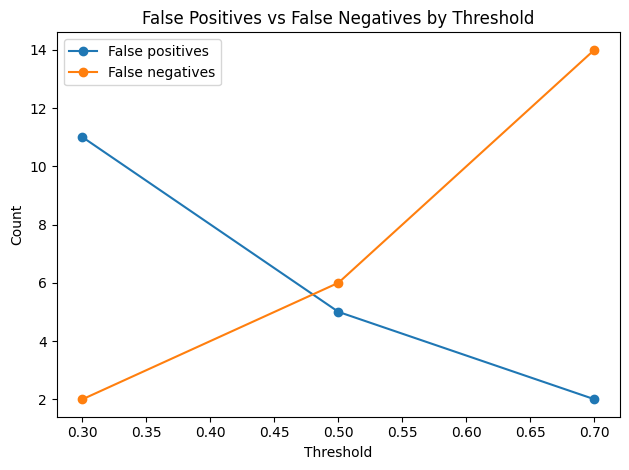

In [84]:
plt.figure()
plt.plot(
    summary_df["threshold"],
    summary_df["false_positives"],
    marker="o",
    label="False positives",
)
plt.plot(
    summary_df["threshold"],
    summary_df["false_negatives"],
    marker="o",
    label="False negatives",
)

plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("False Positives vs False Negatives by Threshold")
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "threshold_tradeoff.png")
plt.show()

## Fintech interpretation

This is where the experiment becomes more than a model evaluation exercise.

A lower threshold may catch more risky cases, but it may also increase false positives.

In fraud detection, that could mean blocking more genuine customers.

In affordability checks, it could mean sending more customers into manual review or decline paths.

A higher threshold may reduce false positives and customer friction, but it may also increase false negatives.

In fraud detection, that could mean allowing more fraud through.

In credit risk, it could mean missing more genuinely risky cases.

The model provides a signal.

The threshold turns that signal into an action.

That action has business, customer, risk, and operational consequences.

## Reflection

The model did not change.

The probability scores did not change.

But the decision outcome changed because the threshold changed.

At a lower threshold, the system is more sensitive and flags more cases.

At a higher threshold, the system is stricter about what it flags, but it may miss more positive cases.

In a fintech context, this means the threshold can affect fraud detection, affordability checks, onboarding friction, manual review volumes, and customer outcomes.

The threshold is not just a technical parameter.

It is a product decision.